In [1]:
# Customer Churn Analysis — UCI Online Retail Dataset
# Load Data and First look
import pandas as pd
import numpy as np
df = pd.read_excel("Online Retail.xlsx", dtype={"CustomerID": str})

In [2]:
# FIRST LOOK - Getting to know the data
print("Shapes:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nDatatypes:\n", df.dtypes)
print("\n First5Rows\n")
df.head()

Shapes: (541909, 8)

Columns:
 ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Datatypes:
 InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object

 First5Rows



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [3]:
# How many Unique Customers
print("No of Unique Customers:",df["CustomerID"].nunique())
# Customers without CustomerID
print("Customers without ID:",df["CustomerID"].isna().sum())
print("That is:", round(df["CustomerID"].isna().mean()*100,1),"% of all rows")
# Date Range of the Data
df["InvoiceDate"]= pd.to_datetime(df["InvoiceDate"])
print("Date Range:", df["InvoiceDate"].min(),"-",df["InvoiceDate"].max())

No of Unique Customers: 4372
Customers without ID: 135080
That is: 24.9 % of all rows
Date Range: 2010-12-01 08:26:00 - 2011-12-09 12:50:00


In [4]:
# Any negative quantity - indicates(Return/Cancellation)
print("Negative Quantities:", (df["Quantity"]<0).sum())
df.describe()

Negative Quantities: 10624


,Quantity,InvoiceDate,UnitPrice
count,541909.000000,541909,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 11:34:00,1.250000
50%,3.000000,2011-07-19 17:17:00,2.080000
75%,10.000000,2011-10-19 11:27:00,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,218.081158,NaN,96.759853


In [5]:
#step2
#Data Cleaning
rows_raw = df.shape[0]
print(f"Starting Rows:",{rows_raw})

Starting Rows: {541909}


In [6]:
#Drop rows with no CustomerID
df = df.dropna(subset=["CustomerID"])
print(f"After dropping rows with no ID:{df.shape[0]}:rows dropped :{rows_raw-df.shape[0]}")

After dropping rows with no ID:406829:rows dropped :135080


In [7]:
#Remove Cancellation where InvoiceNo starts with "C"
df=df[~df["InvoiceNo"].astype(str).str.startswith("C")]
print(f"After Removing Cancellation:{df.shape[0]}")

After Removing Cancellation:397924


In [8]:
#Remove rows with quantity and unit price less than 0
df=df[df["Quantity"]>0]
df =df[df["UnitPrice"]>0]
print(f"After Removing Invalid Quantities/Price:{df.shape[0]}")

After Removing Invalid Quantities/Price:397884


In [9]:
#Drop Duplicate Rows
df=df.drop_duplicates()
print(f"After Dropping Duplicates:{df.shape[0]}")

After Dropping Duplicates:392692


In [10]:
#Parse the date and clean CustomerID type
df["InvoiceDate"]= pd.to_datetime(df["InvoiceDate"])
df["CustomerID"]= df["CustomerID"].astype(str).str.strip()
df["OrderDate"]=df["InvoiceDate"].dt.date


In [11]:
#Create the Revenue Coloumn
df["Revenue"]= df['Quantity']*df['UnitPrice']
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,OrderDate,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,2010-12-01,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,2010-12-01,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,2010-12-01,20.34


In [12]:
# Reference date: one day after last transaction
reference_date = pd.Timestamp('2011-12-10')
#Group by customers and get aggregates
customer_df = df.groupby("CustomerID").agg(
    first_purchase = ("InvoiceDate", "min"),
    last_purchase = ("InvoiceDate", "max"),
    total_orders = ("InvoiceNo", "nunique"),
    total_revenue = ("Revenue", "sum"),
    total_items = ("Quantity", "sum")
).reset_index()



In [13]:
#last day since the last purchase
customer_df["day_since_last"]=(reference_date-customer_df["last_purchase"]).dt.days

In [14]:
#Churn flag: inactive for more than 90 days
customer_df["churned"] = (customer_df["day_since_last"]>90).astype(int)

In [15]:
# Average order value
customer_df["avg_order_value"] =customer_df["total_revenue"]/customer_df["total_orders"]

In [16]:
print("\nPreview of Customers Table\n")
print(customer_df.shape)
customer_df.head()



Preview of Customers Table

(4338, 9)


,CustomerID,first_purchase,last_purchase,total_orders,total_revenue,total_items,day_since_last,churned,avg_order_value
0,12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,77183.60,74215,325,1,77183.600000
1,12347,2010-12-07 14:57:00,2011-12-07 15:52:00,7,4310.00,2458,2,0,615.714286
2,12348,2010-12-16 19:09:00,2011-09-25 13:13:00,4,1797.24,2341,75,0,449.310000
3,12349,2011-11-21 09:51:00,2011-11-21 09:51:00,1,1757.55,631,18,0,1757.550000
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,197,310,1,334.400000


In [17]:
#Headline KPIs
total_customer = len(customer_df)
is_churned =customer_df["churned"].sum()
churn_rate= is_churned/total_customer
retained = total_customer-is_churned
repeat_buyers = (customer_df["total_orders"]>1).sum()
repeat_rate = retained/total_customer
one_time_buyers = (customer_df["total_orders"]==1).sum()
average_ltv  = customer_df['total_revenue'].mean()


In [18]:
print("="*45)
print("  CUSTOMER CHURN — HEADLINE KPIs")
print("="*45)
print(f"Total Customers:      {total_customer:,}")
print(f"Churned (>90 days):   {is_churned:,} ({churn_rate:.1%})")
print(f"Retained:           { retained:,} ({1-churn_rate:.1%})")
print(f"One-time buyers:    {one_time_buyers:,} ({one_time_buyers/total_customer:.1%})")
print(f"Repeat purchase rate: {repeat_rate:.1%}")
print(f"Avg customer LTV:    {average_ltv:,.2f}")
print("="*45)

  CUSTOMER CHURN — HEADLINE KPIs
Total Customers:      4,338
Churned (>90 days):   1,449 (33.4%)
Retained:           2,889 (66.6%)
One-time buyers:    1,493 (34.4%)
Repeat purchase rate: 66.6%
Avg customer LTV:    2,048.69


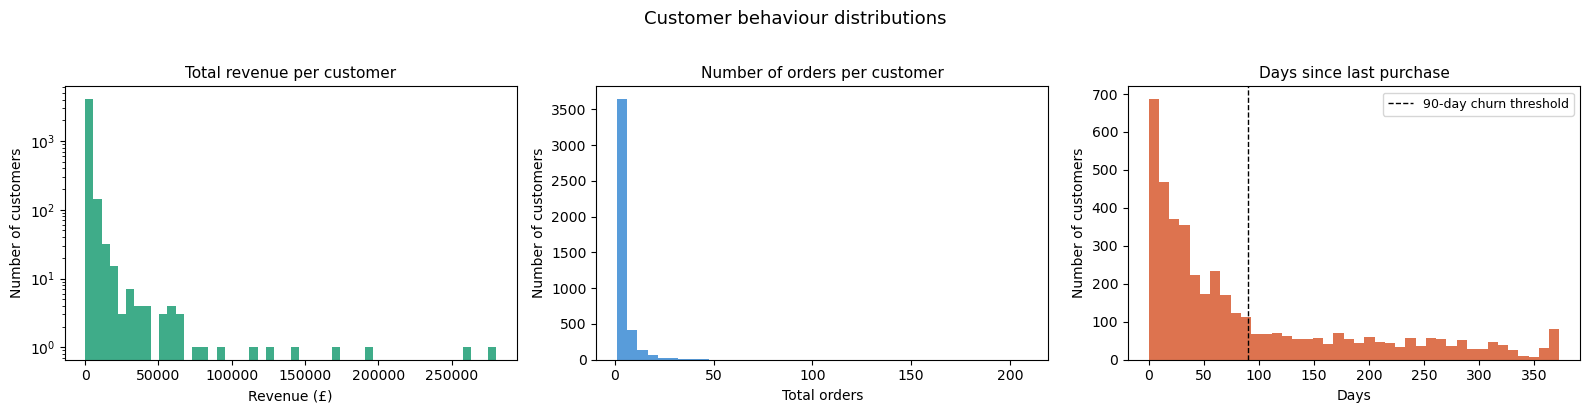

Saved: customer_distributions.png


In [19]:
# DEEPER DIAGNOSTIC — don't skip this
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Customer behaviour distributions', fontsize=13, fontweight='500', y=1.02)

# --- Plot 1: Revenue distribution (log scale to handle skew) ---
axes[0].hist(customer_df['total_revenue'], bins=50, color='#1D9E75', edgecolor='none', alpha=0.85)
axes[0].set_title('Total revenue per customer', fontsize=11)
axes[0].set_xlabel('Revenue (£)')
axes[0].set_ylabel('Number of customers')
axes[0].set_yscale('log')

# --- Plot 2: Orders distribution ---
axes[1].hist(customer_df['total_orders'], bins=40, color='#3B8BD4', edgecolor='none', alpha=0.85)
axes[1].set_title('Number of orders per customer', fontsize=11)
axes[1].set_xlabel('Total orders')
axes[1].set_ylabel('Number of customers')

# --- Plot 3: Days since last purchase ---
axes[2].hist(customer_df['day_since_last'], bins=40, color='#D85A30', edgecolor='none', alpha=0.85)
axes[2].axvline(x=90, color='black', linestyle='--', linewidth=1, label='90-day churn threshold')
axes[2].set_title('Days since last purchase', fontsize=11)
axes[2].set_xlabel('Days')
axes[2].set_ylabel('Number of customers')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig('customer_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: customer_distributions.png")

In [20]:
# REVENUE PERCENTILE BREAKDOWN
# This tells you how skewed LTV really is
percentiles = [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
rev_percentiles = customer_df['total_revenue'].quantile(percentiles)

print("Revenue distribution:")
print("-" * 35)
for p, v in zip(percentiles, rev_percentiles):
    print(f"  {int(p*100):>3}th percentile:   £{v:>8,.0f}")

print(f"\n  Mean (avg LTV):      £{customer_df['total_revenue'].mean():>8,.0f}")
print(f"  Median LTV:          £{customer_df['total_revenue'].median():>8,.0f}")

# How much revenue do the top 20% of customers generate?
top20_threshold = customer_df['total_revenue'].quantile(0.80)
top20_revenue   = customer_df[customer_df['total_revenue'] >= top20_threshold]['total_revenue'].sum()
total_revenue   = customer_df['total_revenue'].sum()

print(f"\n  Top 20% customers generate: £{top20_revenue:,.0f}")
print(f"  That's {top20_revenue/total_revenue:.1%} of total revenue")
print(f"\n  Total revenue in dataset:   £{total_revenue:,.0f}")

Revenue distribution:
-----------------------------------
   25th percentile:   £     306
   50th percentile:   £     669
   75th percentile:   £   1,661
   90th percentile:   £   3,641
   95th percentile:   £   5,790
   99th percentile:   £  19,780

  Mean (avg LTV):      £   2,049
  Median LTV:          £     669

  Top 20% customers generate: £6,637,301
  That's 74.7% of total revenue

  Total revenue in dataset:   £8,887,209


In [21]:
# WIN-BACK OPPORTUNITY ANALYSIS
# Segment churned customers by how recoverable they are
# Segment churned customers by recency
def churn_segment(days):
    if days <= 180:
        return '1. Recently churned (90–180 days)'
    elif days <= 270:
        return '2. Moderately lapsed (181–270 days)'
    else:
        return '3. Deeply lapsed (271+ days)'

churned_df = customer_df[customer_df['churned'] == 1].copy()
churned_df['churn_segment'] = churned_df['day_since_last'].apply(churn_segment)

summary = churned_df.groupby('churn_segment').agg(
    customers       = ('CustomerID',    'count'),
    median_ltv      = ('total_revenue', 'median'),
    total_lost_rev  = ('total_revenue', 'sum'),
    avg_orders      = ('total_orders',  'mean')
).reset_index()

summary['pct_of_churned'] = (summary['customers'] / len(churned_df) * 100).round(1)

print("=" * 62)
print("   WIN-BACK OPPORTUNITY — CHURNED CUSTOMER SEGMENTS")
print("=" * 62)
for _, row in summary.iterrows():
    print(f"\n  {row['churn_segment']}")
    print(f"    Customers:          {row['customers']:,}  ({row['pct_of_churned']}% of churned)")
    print(f"    Median LTV:         £{row['median_ltv']:,.0f}")
    print(f"    Total revenue:      £{row['total_lost_rev']:,.0f}")
    print(f"    Avg orders placed:  {row['avg_orders']:.1f}")


   WIN-BACK OPPORTUNITY — CHURNED CUSTOMER SEGMENTS

  1. Recently churned (90–180 days)
    Customers:          591  (40.8% of churned)
    Median LTV:         £530
    Total revenue:      £478,273
    Avg orders placed:  2.4

  2. Moderately lapsed (181–270 days)
    Customers:          473  (32.6% of churned)
    Median LTV:         £316
    Total revenue:      £323,258
    Avg orders placed:  1.6

  3. Deeply lapsed (271+ days)
    Customers:          385  (26.6% of churned)
    Median LTV:         £263
    Total revenue:      £231,011
    Avg orders placed:  1.4


In [22]:
# ============================================================
# ONE-TIME BUYER DEEP DIVE
# These are your highest-churn-risk customers
# ============================================================

one_time = customer_df[customer_df['total_orders'] == 1]
repeat   = customer_df[customer_df['total_orders'] >  1]

print("One-time buyers vs repeat buyers")
print("-" * 40)
print(f"  One-time buyer churn rate:   "
      f"{one_time['churned'].mean():.1%}")
print(f"  Repeat buyer churn rate:     "
      f"{repeat['churned'].mean():.1%}")
print(f"\n  Median LTV — one-time:       £{one_time['total_revenue'].median():,.0f}")
print(f"  Median LTV — repeat:         £{repeat['total_revenue'].median():,.0f}")
print(f"\n  One-time buyers churned:     {one_time['churned'].sum():,}")
print(f"  Revenue from churned one-timers: "
      f"£{one_time[one_time['churned']==1]['total_revenue'].sum():,.0f}")

One-time buyers vs repeat buyers
----------------------------------------
  One-time buyer churn rate:   56.7%
  Repeat buyer churn rate:     21.2%

  Median LTV — one-time:       £256
  Median LTV — repeat:         £1,154

  One-time buyers churned:     847
  Revenue from churned one-timers: £356,240


In [23]:
# ============================================================
# PHASE 3 — RFM SEGMENTATION
# ============================================================

# Score each customer 1-4 on Recency, Frequency, Monetary
# 4 = best, 1 = worst

# Recency: lower days_since_last = better = higher score
customer_df['R_score'] = pd.qcut(
    customer_df['day_since_last'],
    q=4, labels=[4, 3, 2, 1]   # reversed: fewer days = score 4
).astype(int)

# Frequency: more orders = better = higher score
customer_df['F_score'] = pd.qcut(
    customer_df['total_orders'].rank(method='first'),
    q=4, labels=[1, 2, 3, 4]
).astype(int)

# Monetary: more revenue = better = higher score
customer_df['M_score'] = pd.qcut(
    customer_df['total_revenue'].rank(method='first'),
    q=4, labels=[1, 2, 3, 4]
).astype(int)

# Combined RFM score string e.g. "444", "111"
customer_df['RFM_score'] = (
    customer_df['R_score'].astype(str) +
    customer_df['F_score'].astype(str) +
    customer_df['M_score'].astype(str)
)

# ============================================================
# ASSIGN SEGMENT LABELS
# ============================================================

def assign_segment(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'
    elif r >= 3 and f >= 3:
        return 'Loyal customers'
    elif r >= 3 and f <= 2:
        return 'Promising'
    elif r == 2 and f >= 3:
        return 'At risk'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'High value lapsed'
    else:
        return 'Lost'

customer_df['segment'] = customer_df.apply(assign_segment, axis=1)

# ============================================================
# SEGMENT SUMMARY
# ============================================================

seg_summary = customer_df.groupby('segment').agg(
    customers       = ('CustomerID',    'count'),
    churn_rate      = ('churned',    'mean'),
    median_ltv      = ('total_revenue', 'median'),
    median_orders   = ('total_orders',  'median'),
    total_revenue   = ('total_revenue', 'sum')
).reset_index().sort_values('total_revenue', ascending=False)

seg_summary['churn_rate'] = (seg_summary['churn_rate'] * 100).round(1)
seg_summary['pct_customers'] = (
    seg_summary['customers'] / seg_summary['customers'].sum() * 100
).round(1)

print("=" * 70)
print("   RFM SEGMENT SUMMARY")
print("=" * 70)
print(f"{'Segment':<22} {'Customers':>10} {'Churn%':>8} "
      f"{'Med LTV':>10} {'Med Orders':>12} {'Total Rev':>12}")
print("-" * 70)
for _, row in seg_summary.iterrows():
    print(f"  {row['segment']:<20} {row['customers']:>10,} "
          f"{row['churn_rate']:>7.1f}% "
          f"£{row['median_ltv']:>9,.0f} "
          f"{row['median_orders']:>12.0f} "
          f"£{row['total_revenue']:>11,.0f}")
print("=" * 70)

   RFM SEGMENT SUMMARY
Segment                 Customers   Churn%    Med LTV   Med Orders    Total Rev
----------------------------------------------------------------------
  Champions                   482     0.0% £    3,970           11 £  4,406,718
  Loyal customers           1,037     0.0% £    1,258            4 £  2,170,313
  At risk                     469    36.2% £    1,220            4 £    774,876
  Lost                      1,426    78.5% £      296            1 £    624,188
  Promising                   657     0.0% £      353            1 £    494,731
  High value lapsed           267    59.9% £      978            2 £    416,383


In [24]:
# ============================================================
# EXPORT TO POWER BI
# Run this at the end of your notebook
# ============================================================

# Main customer table — this is your primary Power BI table
customer_df.to_csv('customer_churn.csv', index=False)

# Segment summary — for your donut/bar charts
seg_export = customer_df.groupby('segment').agg(
    customers       = ('CustomerID',    'count'),
    is_churned         = ('churned',    'sum'),
    churn_rate      = ('churned',    'mean'),
    median_ltv      = ('total_revenue', 'median'),
    total_revenue   = ('total_revenue', 'sum')
).reset_index()
seg_export['churn_rate'] = (seg_export['churn_rate'] * 100).round(1)
seg_export.to_csv('segment_summary.csv', index=False)

# Win-back priority list — for the campaign targeting visual
winback = customer_df[
    (customer_df['segment'].isin(['At risk', 'High value lapsed'])) &
    (customer_df['churned'] == 1)
][['CustomerID', 'segment', 'day_since_last',
   'total_orders', 'total_revenue', 'last_purchase']].copy()
winback = winback.sort_values('total_revenue', ascending=False)
winback.to_csv('winback_targets.csv', index=False)

print("Exported 3 files:")
print(f"  customer_churn.csv     — {len(customer_df):,} rows")
print(f"  segment_summary.csv    — {len(seg_export):,} rows")
print(f"  winback_targets.csv    — {len(winback):,} rows")

Exported 3 files:
  customer_churn.csv     — 4,338 rows
  segment_summary.csv    — 6 rows
  winback_targets.csv    — 330 rows


In [25]:
# ============================================================
# EXPORT TO POWER BI
# Run this at the end of your notebook
# ============================================================

# Main customer table — this is your primary Power BI table
customer_df.to_csv('customer_churn.csv', index=False)

# Segment summary — for your donut/bar charts
seg_export = customer_df.groupby('segment').agg(
    customers       = ('CustomerID',    'count'),
    is_churned         = ('churned',    'sum'),
    churn_rate      = ('churned',    'mean'),
    median_ltv      = ('total_revenue', 'median'),
    total_revenue   = ('total_revenue', 'sum')
).reset_index()
seg_export['churn_rate'] = (seg_export['churn_rate'] * 100).round(1)
seg_export.to_csv('segment_summary.csv', index=False)

# Win-back priority list — for the campaign targeting visual
winback = customer_df[
    (customer_df['segment'].isin(['At risk', 'High value lapsed'])) &
    (customer_df['churned'] == 1)
][['CustomerID', 'segment', 'day_since_last',
   'total_orders', 'total_revenue', 'last_purchase']].copy()
winback = winback.sort_values('total_revenue', ascending=False)
winback.to_csv('winback_targets.csv', index=False)

print("Exported 3 files:")
print(f"  customer_churn.csv     — {len(customer_df):,} rows")
print(f"  segment_summary.csv    — {len(seg_export):,} rows")
print(f"  winback_targets.csv    — {len(winback):,} rows")

Exported 3 files:
  customer_churn.csv     — 4,338 rows
  segment_summary.csv    — 6 rows
  winback_targets.csv    — 330 rows


In [26]:
import os
print(os.getcwd())

C:\Users\Esther


In [27]:
# ============================================================
# PROJECT SUMMARY STATS FOR README
# ============================================================

total_rev       = customer_df['total_revenue'].sum()
churn_rate      = customer_df['churned'].mean()
one_time_churn  = customer_df[customer_df['total_orders']==1]['churned'].mean()
repeat_churn    = customer_df[customer_df['total_orders']>1]['churned'].mean()
priority_cust   = 330
recovery_rev    = 49 * 1090  # 15% of 330 × median LTV

print("README STATS")
print(f"  Dataset rows (raw):        541,909")
print(f"  Customers analysed:        {len(customer_df):,}")
print(f"  Overall churn rate:        {churn_rate:.1%}")
print(f"  One-time buyer churn:      {one_time_churn:.1%}")
print(f"  Repeat buyer churn:        {repeat_churn:.1%}")
print(f"  Total revenue in dataset:  £{total_rev:,.0f}")
print(f"  Priority win-back targets: {priority_cust}")
print(f"  Est. recovery revenue:     £{recovery_rev:,}")

README STATS
  Dataset rows (raw):        541,909
  Customers analysed:        4,338
  Overall churn rate:        33.4%
  One-time buyer churn:      56.7%
  Repeat buyer churn:        21.2%
  Total revenue in dataset:  £8,887,209
  Priority win-back targets: 330
  Est. recovery revenue:     £53,410
